# Analysis
This notebook contains the code for the analysis of the dataset, its features as well as of annotations and annotators as well as the code for creating graphs from these. For analysis of model performance, see models.ipynb.

In [1]:
import matplotlib.pyplot as plt, json, math, numpy as np, sklearn, random
from scipy.stats import pearsonr, spearmanr
from collections import Counter
from nltk.probability import FreqDist
from sklearn.metrics import cohen_kappa_score
from statsmodels.stats import inter_rater as irr
from scipy.stats import ttest_ind

In [2]:
with open("all_features.json", "r") as f:
    all_features = json.load(f)

In [3]:
def get_total_freq(compound):
    return sum(all_features[compound][feat] for feat in all_features[compound].keys() if feat.startswith("abs_freq"))

## Compound frequency

[0, 2, 13, 89, 43, 30, 23]


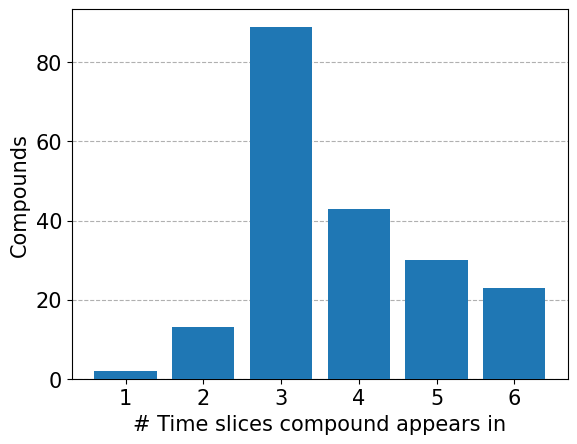

In [4]:
number_of_bins = [0] * 7
for compound, features in all_features.items():
    n = sum([bool(value) for value in list(features.values())[:6]])
    # if n==1:
    #     print(compound, features)
    number_of_bins[n] += 1
print(number_of_bins)
plt.rc('axes', labelsize=15)
plt.rc('ytick', labelsize=15)
plt.rc('xtick', labelsize=15)
#plt.figure(figsize=(8, 4.5))
plt.bar(range(1,7), number_of_bins[1:], zorder=3)
plt.xlabel("# Time slices compound appears in")
plt.ylabel("Compounds")
plt.grid(axis='y', zorder=0, linestyle='--')
plt.show()

[0, 28, 56, 96, 191, 195, 189]


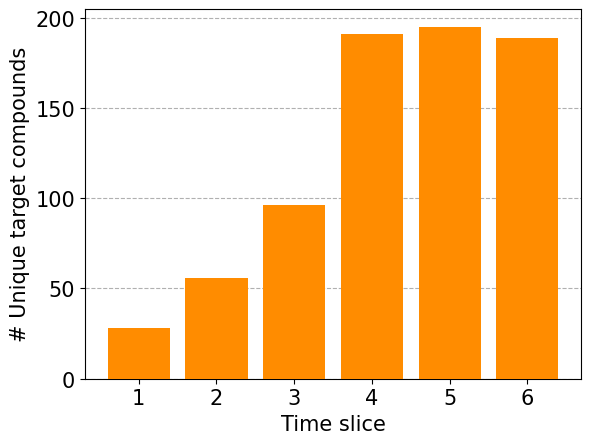

In [16]:
compounds_by_bin = [0] * 7
for compound, features in all_features.items():
    for i in range(1,7):
        if features[f"abs_freq_bin{i}"] > 0:
            compounds_by_bin[i] += 1
print(compounds_by_bin)
plt.bar(range(1,7), compounds_by_bin[1:], color="darkorange", zorder=3)
plt.grid(axis='y', zorder=0, linestyle='--')
plt.xlabel("Time slice")
plt.ylabel("# Unique target compounds")
plt.show()
plt.rcdefaults()

In [4]:
counts = []
for compound in all_features.keys():
    counts.append(get_total_freq(compound))
print(len(counts))
print(all(counts))
print(np.median(counts))

200
True
205.5


In [8]:
## tokens per topic
tokens_per_topic = {0: 49800052, 1: 56289785, 2: 50166822, 3: 43601492, 4: 35848760, 5: 26924671, 6: 16833937, 7: 8506502, 8: 4706581, 9: 2033003, 10: 710126, 11: 233350, 12: 86521, 13: 15007, 14: 9934, 15: 0, 16: 0, 17: 19, 18: 0, 19: 0, 20: 0, 21: 0, 22: 0, 23: 0, 24: 8, 25: 0, 26: 0, 27: 0, 28: 10, 29: 28}

In [8]:
head_freqs = []
mod_freqs = []
for c, features in all_features.items():
    mod_freqs.append(features["mod_freq_bin6"])
    head_freqs.append(features["head_freq_bin6"])
print("Heads: ", np.median(head_freqs) * 172.018539)
print("Mods: ", np.median(mod_freqs) * 172.018539)


Heads:  54867.99999999999
Mods:  11078.0


## Paraphrases

temperature effect 1615
water surface 964
air temperature 1165
oxygen pressure 591
gas pressure 765
temperature change 1368
6
more paras:  13
{1: 21, 2: 57, 3: 93, 4: 140, 5: 133, 6: 110}
[1.0087282504433817e-07, 5.478921603175028e-07, 9.147003261754416e-07, 6.256519404049562e-07, 4.264773002509014e-07, 1.0658734870431612e-07]


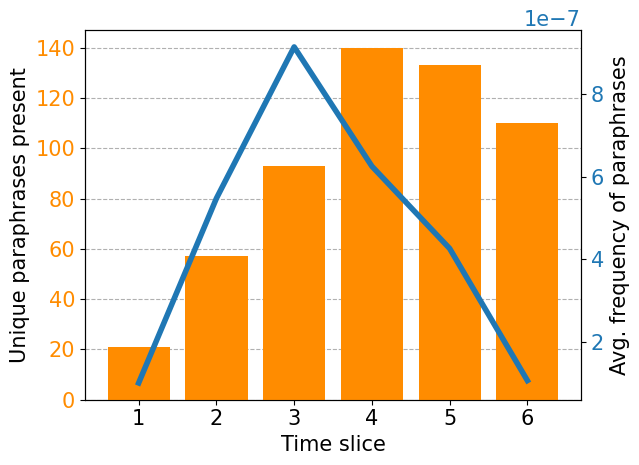

{0: 34, 1: 21, 2: 25, 3: 44, 4: 43, 5: 19, 6: 14}


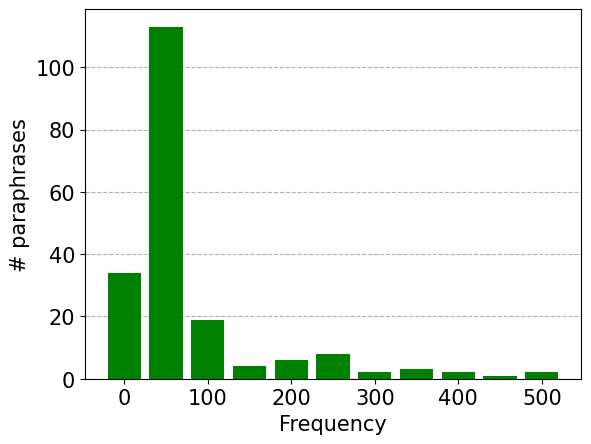

In [6]:
counter_500 = 0
counter_more_paras = 0
para_by_bins = {i:0 for i in range(1,7)}
para_by_number_of_bins = {i:0 for i in range(7)}
para_by_freq = []
paras_rel_freqs = [0] * 6
for compound, features in all_features.items():
    paras = np.array([val for key, val in features.items() if "abs_para" in key])
    for bin in range(len(paras_rel_freqs)):
        paras_rel_freqs[bin] += features[f"para_freq_bin{bin+1}"]/(200 * 1e6)
    for i, freq in enumerate(paras):
        if freq > 0:
            para_by_bins[i+1] += 1
    para_by_number_of_bins[np.count_nonzero(paras)] += 1
    if sum(paras) > 500:
        counter_500 +=1
        print(compound, sum(paras)) 
    else:
        para_by_freq.append((49 + sum(paras))//50 * 50)
    if sum(paras) > get_total_freq(compound):
        counter_more_paras += 1
print(counter_500)
print("more paras: ", counter_more_paras)

para_by_freq = FreqDist(para_by_freq)
print(dict(para_by_bins))
print(paras_rel_freqs)

plt.rc('axes', labelsize=15)
plt.rc('ytick', labelsize=15)
plt.rc('xtick', labelsize=15)
plt.bar(para_by_bins.keys(), para_by_bins.values(), zorder=3, color="darkorange")
plt.grid(axis='y', zorder=0, linestyle='--')
plt.xlabel("Time slice")
plt.ylabel("Unique paraphrases present")
plt.tick_params(axis='y', labelcolor = 'darkorange')
axes = plt.gca()
axes2 = axes.twinx()
axes2.plot(para_by_bins.keys(), paras_rel_freqs, linewidth=4, color="tab:blue")
axes2.tick_params(labelcolor = 'tab:blue')
axes2.set_ylabel("Avg. frequency of paraphrases")
plt.show()
# print(para_by_number_of_bins)
# plt.bar(para_by_number_of_bins.keys(), para_by_number_of_bins.values())
# plt.show()
print(dict(para_by_number_of_bins))
plt.bar(para_by_freq.keys(), para_by_freq.values(), width=40, zorder=3, color="green")
plt.grid(axis='y', zorder=0, linestyle='--')
plt.xlabel("Frequency")
plt.ylabel("# paraphrases")
plt.show()
plt.rcdefaults()


## Annotations

In [4]:
def get_bad_annotators():
    bad_ids = []
    for batch in range(8):
        with open(f"annotations/form_urs_{batch}_results_judgements.csv") as f:
            annotator_judgements = {}
            for line in f.readlines()[1:]:
                _, _, anno_id, judgement = line.strip().split(',')
                if anno_id not in annotator_judgements:
                    annotator_judgements[anno_id] = [judgement]
                annotator_judgements[anno_id].append(judgement)
        for anno_id, judgements in annotator_judgements.items():
            if all([j == '5' for j in judgements]):
                bad_ids.append(anno_id)
    print("excluding annotators: ", bad_ids)
    return list(set(bad_ids))

In [5]:
compounds = all_features.keys()
control_items = ["elbow grease", "sex bomb", "lime tree", "milk tooth", "silver lining", "nut case", "insurance company", "mental disorder"]
controls_for = {item:what_for for item, what_for in zip(control_items, ["low_head", "low_head", "high_head", "high_head", "low_mod", "low_mod", "high_mod", "high_mod"])}

def get_all_judgements():
    bad_annotators = get_bad_annotators()
    mod_judgements = {compound: [] for compound in compounds}
    head_judgements = {compound: [] for compound in compounds}

    for batch in range(8):
        with open(f"annotations/form_urs_{batch}_results_judgements.csv") as f:
            for line in f.readlines()[1:]:
                compound, constituent, anno_id, judgement = line.strip().split(',')
                if compound in control_items or anno_id in bad_annotators:
                    continue
                mod, head = compound.split()
                if constituent == mod:
                    mod_judgements[compound].append(int(judgement))
                elif constituent == head:
                    head_judgements[compound].append(int(judgement))
                else:
                    raise Exception("Unclear constituent")
    return [(compound, np.average(mod_judgements[compound]), np.average(head_judgements[compound])) for compound in all_features.keys() if mod_judgements[compound]]

all_annotated_compounds = get_all_judgements()
#print(annotated_compounds)
print(len(all_annotated_compounds))

excluding annotators:  ['6666c3db060bd8e20ca975cd', '660d5af29e8f6f8ac3be3749', '60e769ec9858960e8ad00886']
200


In [6]:
mod0_head1 = 1
constituent = ["modifier", "head"][mod0_head1]
if mod0_head1: #if head:
    annotated_compounds = [(comp, head_score) for comp, mod_score, head_score in all_annotated_compounds]
else:
    annotated_compounds = [(comp, mod_score) for comp, mod_score, head_score in all_annotated_compounds]

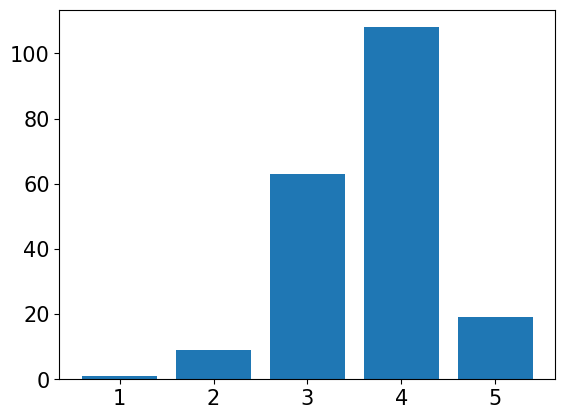

low comp score wrt modifier 10 ['luminosity curve', 'side tube', 'contact theory', 'plate glass', 'object glass', 'crown glass', 'silver salt', 'extensor muscle', 'motor region', 'penny weight']


In [9]:
rounded_vals = [round(x[1]) for x in annotated_compounds]
counts = Counter(rounded_vals)
plt.bar(counts.keys(), counts.values())
plt.show()
below_avg = sum([x[1] <= 2.5 for x in annotated_compounds])
below_avg_compounds = [x[0] for x in annotated_compounds if x[1] <= 2.5]
print(f"low comp score wrt {constituent}", below_avg, below_avg_compounds)

In [7]:
annotated_compounds.sort(key=lambda x:x[1]) # sort by annotation score for either head or mod
targets_low = annotated_compounds[:60]
targets_high = annotated_compounds[-60:]
print("lowest: ", annotated_compounds[0])
print("highest: ", annotated_compounds[-1])

low_values = np.array([x[1] for x in targets_low])
high_values = np.array([x[1] for x in targets_high])
print(constituent)
print(f"Low compositionality targets: Mean {np.average(low_values)}, SD {np.std(low_values)}")
print(f"High compositionality targets: Mean {np.average(high_values)}, SD {np.std(high_values)}")

lowest:  ('viscosity work', 1.3846153846153846)
highest:  ('rain water', 5.0)
head
Low compositionality targets: Mean 2.8362881562881563, SD 0.3913501689605243
High compositionality targets: Mean 4.314822954822955, SD 0.27153402062424037


excluding annotators:  ['6666c3db060bd8e20ca975cd', '660d5af29e8f6f8ac3be3749', '60e769ec9858960e8ad00886']
(5.0, 4.666666666666667)
(4.066666666666666, 4.0, 1.3846153846153846, 5.0) (1.4666666666666666, 4.785714285714286, 3.6153846153846154, 4.666666666666667)


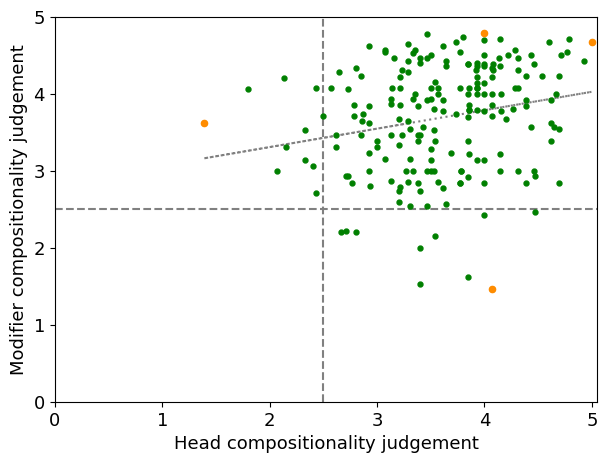

SignificanceResult(statistic=0.2528202581688555, pvalue=0.0003040057916348322)


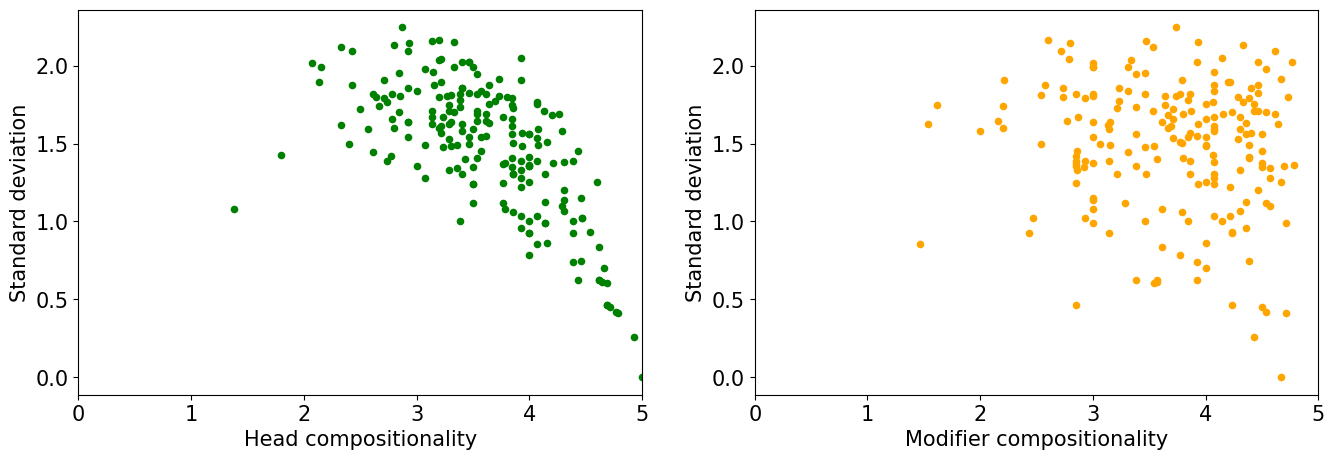

In [ ]:
extremes = ["penny weight", "day time", "viscosity work", "rain water"]
bad_annos = get_bad_annotators()
def get_scores_for_compound(my_compound):
    mod_scores = []
    head_scores = []
    for batch in range(8):
        with open(f"annotations/form_urs_{batch}_results_judgements.csv") as f:
            for line in f.readlines()[1:]:
                compound, judged_constituent, anno_id, judgement = line.strip().split(',')
                if compound == my_compound and anno_id not in bad_annos:
                    if judged_constituent == compound.split()[0]:
                        mod_scores.append(float(judgement))
                    else:
                        head_scores.append(float(judgement))
    return (np.average(head_scores), np.average(mod_scores))


def get_judgements_with_sd(constituent="head", just_control_items=False):
    judgements = {compound: [] for compound in compounds}
    control_items = ["elbow grease", "sex bomb", "lime tree", "mental disorder", "milk tooth", "silver lining", "nut case", "insurance company"]
    if just_control_items:
        judgements = {compound: [] for compound in control_items}

    for batch in range(8):
        with open(f"annotations/form_urs_{batch}_results_judgements.csv") as f:
            for line in f.readlines()[1:]:
                compound, judged_constituent, anno_id, judgement = line.strip().split(',')
                if anno_id in bad_annos or ((compound in control_items) != just_control_items): #this is an xor
                    continue 
                desired_constituent = compound.split()[{"mod": 0, "head": 1}[constituent]]
                if judged_constituent == desired_constituent:
                    judgements[compound].append(int(judgement))
    return [np.average(judgements[compound]) for compound in judgements.keys() if judgements[compound]], \
            [np.std(judgements[compound]) for compound in judgements.keys() if judgements[compound]], \
            [compound for compound in judgements.keys() if judgements[compound]]

#plot head against mod judgements
plt.rc('axes', labelsize=13)
plt.rc('ytick', labelsize=13)
plt.rc('xtick', labelsize=13)
judgements_head, judgements_mod = get_judgements_with_sd("head")[0], get_judgements_with_sd("mod")[0]
f = plt.figure(figsize=(7, 5))
plt.scatter(judgements_head, judgements_mod, s=50, marker=".", c="green")

z = np.polyfit(judgements_head, judgements_mod, 1)
p = np.poly1d(z)
#plt.plot(judgements_head,p(judgements_head),color="grey", linestyle=":", lw=1.5, zorder=0)

print(get_scores_for_compound("rain water"))
extremes_x, extremes_y = zip(*[get_scores_for_compound(ex) for ex in extremes])
# for i in range(len(extremes)):  
#     plt.text(extremes_x[i] + .02, extremes_y[i] +.01, extremes[i], size=12) 
print(extremes_x, extremes_y)
plt.scatter(extremes_x, extremes_y, s=80, marker=".", c="darkorange")

plt.xlabel("Head compositionality judgement")
plt.ylabel("Modifier compositionality judgement")
axes = plt.gca()
axes.set_ylim([0, 5])
axes.set_xlim([0, 5.05])
axes.axhline(2.5, linestyle='--', color='grey', lw=1.5, zorder=0) 
axes.axvline(2.5, linestyle='--', color='grey', lw=1.5, zorder=0)
plt.show()
print(spearmanr(judgements_head, judgements_mod))

#plot mean v sd for heads ("croissant plot")
plt.rc('axes', labelsize=15)
plt.rc('ytick', labelsize=15)
plt.rc('xtick', labelsize=15)
plt.figure(figsize=(16, 5))
plt.subplot(121)
plt.scatter(judgements_head, get_judgements_with_sd("head")[1], s=20, marker="o", c="green")
axes = plt.gca()
axes.set_xlim([0, 5])
plt.xlabel("Head compositionality")
plt.ylabel("Standard deviation")
plt.subplot(122)
plt.scatter(judgements_mod, get_judgements_with_sd("head")[1], s=20, marker="o", c="orange")
axes = plt.gca()
axes.set_xlim([0, 5])
plt.xlabel("Modifier compositionality")
plt.ylabel("Standard deviation")
plt.show()
plt.rcdefaults()

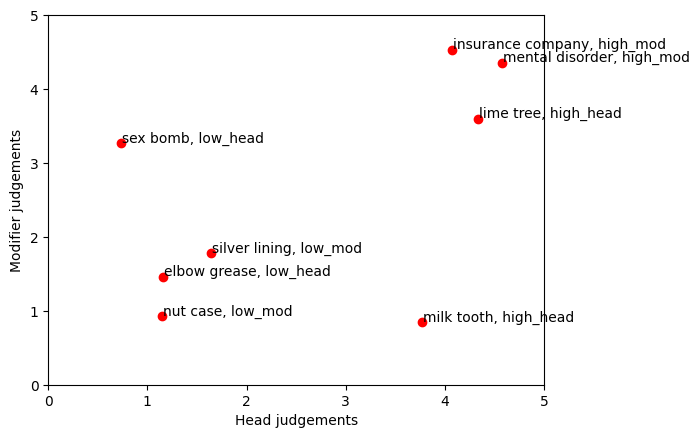

In [15]:
#plt.scatter(get_judgements_with_sd("head", just_control_items=True)[0], get_judgements_with_sd("mod", just_control_items=True)[0])
xs = get_judgements_with_sd("head", just_control_items=True)[0]
ys = get_judgements_with_sd("mod", just_control_items=True)[0]
comps = get_judgements_with_sd("mod", just_control_items=True)[2]
for i in range(len(xs)):
    plt.plot(xs[i], ys[i], 'ro')
    plt.text(xs[i] + .01, ys[i] +.01, comps[i] + ", " + controls_for[comps[i]])

plt.xlabel("Head judgements")
plt.ylabel("Modifier judgements")
axes = plt.gca()
axes.set_ylim([0, 5])
axes.set_xlim([0, 5])
plt.show()

In [16]:
gold_scores = {compound.replace("_", " "): (float(head), float(mod)) for compound, head, mod in [('insurance_company', '4.8889', '5.0000'), ('dead_end', '4.1667', '0.2778'), ('goose_egg', '0.5000', '0.3000'), ('lime_tree', '5.0000', '4.8750'), ('mental_disorder', '5.0000', '5.0000'), ('milk_tooth', '5.0000', '0.8333'), ('elbow_grease', '0.1538', '0.9231'), ('sex_bomb', '0.1765', '2.8824'), ('silver_lining', '0.2222', '0.1667'), ('nut_case', '0.4375', '0.2500')]}
comps = get_judgements_with_sd("mod", just_control_items=True)[2]
heads, sds = get_judgements_with_sd("head", just_control_items=True)[0:2]
mods = get_judgements_with_sd("mod", just_control_items=True)[0]
gold_heads = [gold_scores[comp][0] for comp in comps]
gold_mods = [gold_scores[comp][1] for comp in comps]
print(pearsonr(heads, gold_heads))
print(pearsonr(mods, gold_mods))
print(sds)

PearsonRResult(statistic=0.9797347833427453, pvalue=2.0491296958238396e-05)
PearsonRResult(statistic=0.9495930817529463, pvalue=0.0003082090951435718)
[1.5112986695683461, 1.339983416149452, 1.299572579307862, 1.2936264483053455, 1.9276867824833335, 1.5859716650838942, 1.9219462924391018, 1.691810338726603]


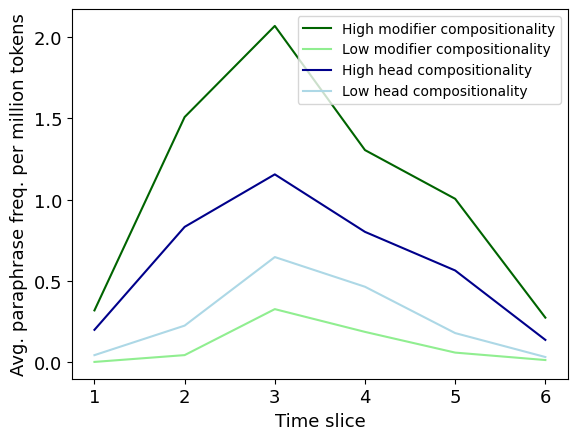

In [18]:
# graph: 60 high v low graph paraphrase freqs over time
timeslices = range(1, 7)
def get_avg_paras_over_time(compounds):
    if type(compounds[0]) == tuple:
        compounds = [c[0] for c in compounds]
    avgs = []
    for bin in timeslices:
        avgs.append(np.average([all_features[compound][f"para_freq_bin{bin}"] for compound in compounds]))
    return avgs

sorted_annotated_compouds = sorted(all_annotated_compounds, key=lambda x:x[1])
mod_high60, mod_low60 = sorted_annotated_compouds[-60:], sorted_annotated_compouds[:60]
sorted_annotated_compouds.sort(key=lambda x:x[2])
head_high60, head_low60 = sorted_annotated_compouds[-60:], sorted_annotated_compouds[:60]

plt.rc('axes', labelsize=13)
plt.rc('ytick', labelsize=13)
plt.rc('xtick', labelsize=13)
plt.xlabel("Time slice")
plt.ylabel("Avg. paraphrase freq. per million tokens")
plt.plot(timeslices, get_avg_paras_over_time(mod_high60), color="darkgreen", label="High modifier compositionality")
plt.plot(timeslices, get_avg_paras_over_time(mod_low60), color="lightgreen", label="Low modifier compositionality")
plt.plot(timeslices, get_avg_paras_over_time(head_high60), color="darkblue", label="High head compositionality")
plt.plot(timeslices, get_avg_paras_over_time(head_low60), color="lightblue", label="Low head compositionality")
#axes = plt.gca()
plt.legend()
plt.show()
plt.rcdefaults()

In [15]:
commonly_misclass = {'parent cell', 'time scale', 'saturation pressure', 'base line', 'minute structure', 'iron tube', 'scale value', 'metal plate', 'foot distance', 'porcelain tube', 'salt solution', 'millimetre scale', 'brass scale', 'power series', 'scale number', 'arm length', 'glass case'}

heads_high = set()
mods_high = set()
heads_low = set()
mods_low = set()
for compound in [c[0] for c in targets_high]:
    mod, head = compound.split()
    heads_high.add(head)
    mods_high.add(mod)
for compound in [c[0] for c in targets_low]:
    mod, head = compound.split()
    heads_low.add(head)
    mods_low.add(mod)

print(heads_high.intersection(heads_low))
mis = [c for c in commonly_misclass if c.split()[1] in heads_high.intersection(heads_low)]
hi = [c[0] for c in targets_high if c[0].split()[1] in heads_high.intersection(heads_low)]
lo = [c[0] for c in targets_low if c[0].split()[1] in heads_high.intersection(heads_low)]

print(len(mis), len(commonly_misclass))
print(len(hi), len(lo))

{'plate', 'salt', 'surface', 'cell', 'distance', 'length', 'cylinder', 'case', 'value', 'scale', 'structure', 'number'}
11 17
19 21


## Annotators

In [ ]:
#negative_annotators = ['62b5db48089258eeb74f68d2', '5f2aad9ef401403198b127b5', '5d45f5d5b2da940001185a30', '66589cb40bba8a88da3c3a88', '63e802622f8052bd67d6c5f0', '66e04be8eee549c122da56b0', '67029f5f16a7fc9fa65529d5', '665f1d07718fd2f868db3aa9', '55c8f30cfdf99b78cc9ea578', '6777db39be1a09bdaa9b79ef', '6728131f684b31c9d5b501ab']
def get_all_judgements(batch, bad_annotators = [], pairwise = False):
    annotator_judgements = {}
    with open(f"annotations/form_urs_{batch}_results_judgements.csv") as f:
        for line in f.readlines()[1:]:
            compound, constituent, anno_id, judgement = line.strip().split(',')
            if anno_id in bad_annotators: #or anno_id in negative_annotators:
                continue
            key = compound + " " + constituent
            if anno_id not in annotator_judgements:
                annotator_judgements[anno_id] = {}
            annotator_judgements[anno_id][key] = int(judgement)
    #print([annotator_judgements[anno]["body weight body"] for anno in annotator_judgements.keys()])
    for anno_id, judgements in annotator_judgements.items():
        annotator_judgements[anno_id] = [value for _, value in sorted(judgements.items(), key=lambda x:x[0])]
    if pairwise:
        for annotator in annotator_judgements.keys():
            correlations = []
            for annotator2 in annotator_judgements.keys():
                if annotator != annotator2:
                    #correlation = pearsonr(annotator_judgements[annotator], annotator_judgements[annotator2]).statistic
                    #correlation = cohen_kappa_score(annotator_judgements[annotator], annotator_judgements[annotator2], labels=range(6))
                    correlation = spearmanr(annotator_judgements[annotator], annotator_judgements[annotator2]).statistic
                    if not math.isnan(correlation):
                        correlations.append(correlation)
                    #print(pearsonr(annotator_judgements[annotator], annotator_judgements[annotator2]).statistic)
            
            if correlations: # and sum(correlations)/len(correlations) < 0:
                print(batch, annotator, sum(correlations)/len(correlations))
                #negative_annotators.append(annotator)
            elif not correlations:
                print(batch, f"annotator {annotator} has constant judgements, i think")
    return annotator_judgements

bad_annotators = get_bad_annotators()
for batch in range(8):
    judgements = list(get_all_judgements(batch, bad_annotators, pairwise=True).values())
    judgements = np.array(judgements).T
    print(judgements[0])
    agg = irr.aggregate_raters(judgements)
    print(irr.fleiss_kappa(agg[0], method='fleiss'))

## Cosine distributions

Mods: 0.36, 0.22
Heads: 0.38, 0.24


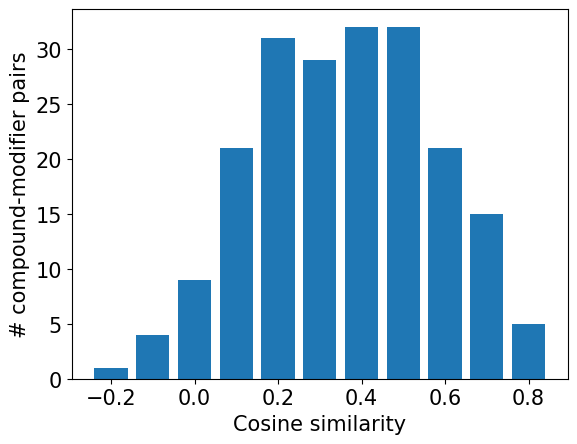

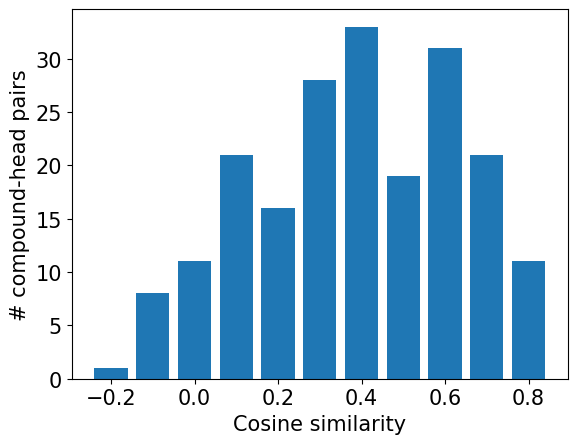

TtestResult(statistic=1.1683718363094138, pvalue=0.24335618023160407, df=398.0)


In [6]:
cosine_sims_mod = []
cosine_sims_head = []
for compound, features in all_features.items():
    cosine_sims_mod.append(features["cosine_mod_bin6"])
    cosine_sims_head.append(features["cosine_head_bin6"])
counts_mod = Counter([round(sim, 1) for sim in cosine_sims_mod])
counts_head = Counter([round(sim, 1) for sim in cosine_sims_head])
print(f"Mods: {np.average(cosine_sims_mod):.2f}, {np.std(cosine_sims_mod):.2f}")
print(f"Heads: {np.average(cosine_sims_head):.2f}, {np.std(cosine_sims_head):.2f}")
#print(counts_mod.keys(), counts_mod.values())

plt.rc('axes', labelsize=15)
plt.rc('ytick', labelsize=15)
plt.rc('xtick', labelsize=15)
plt.bar(counts_mod.keys(), counts_mod.values(), width=.08)
plt.ylabel("# compound-modifier pairs")
plt.xlabel("Cosine similarity")
plt.show()
plt.bar(counts_head.keys(), counts_head.values(), width=.08)
plt.ylabel("# compound-head pairs")
plt.xlabel("Cosine similarity")
plt.show()
plt.rcdefaults()
print(ttest_ind(cosine_sims_head, cosine_sims_mod))

## Target compound clustering

In [49]:
from gensim.models import Word2Vec, KeyedVectors
from sklearn.cluster import DBSCAN, KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA 
vectors = KeyedVectors.load(f"w2v_total/word2vec.wordvectors")


In [ ]:
all_vectors = []
for compound in all_features.keys():
    compound = "_".join(compound.split())
    all_vectors.append(vectors[compound])

print(len(all_vectors))
all_vectors = np.array(all_vectors)

kmeans = KMeans(init="k-means++", n_clusters=4, n_init=4)
preds = kmeans.fit_predict(all_vectors)
#print(preds, len(preds))

200


In [ ]:
# Find ideal number of clusters
sil_score_max = -1 
for n_clusters in range(2,10):
  model = KMeans(n_clusters = n_clusters, init='k-means++', max_iter=100, n_init=1)
  labels = model.fit_predict(all_vectors)
  sil_score = silhouette_score(all_vectors, labels)
  print("The average silhouette score for %i clusters is %0.2f" %(n_clusters,sil_score))
  if sil_score > sil_score_max:
    sil_score_max = sil_score
    best_n_clusters = n_clusters

In [ ]:
print(counts)
# get average head and mod score for each cluster
# code may be missing here

## CCOHA

In [5]:
with open("coha/all_features_coha.json", "r") as f:
    all_features_coha = json.load(f)

158
sea water 299
salt water 841
boundary line 341
room temperature 425
body temperature 257
blood pressure 1299
motive power 435
glass case 259
cross section 329
body weight 300


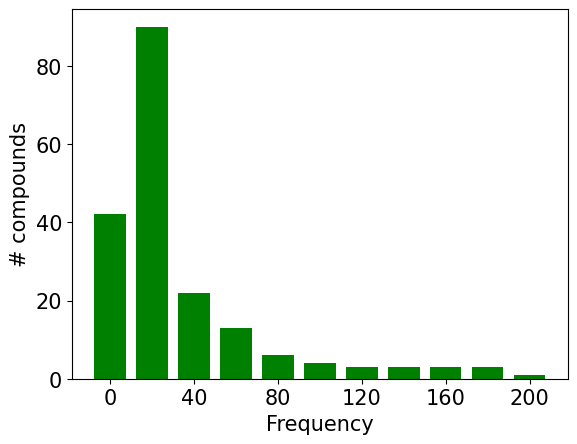

Counter({20: 90, 0: 42, 40: 22, 60: 13, 80: 6, 100: 4, 160: 3, 120: 3, 140: 3, 180: 3, 200: 1}) 10
190


In [ ]:
#plt.rcParams.update(plt.rcdefaults)
plt.rcdefaults()
occs = []
outliers = 0
print(len(all_features_coha))
for c, features in all_features_coha.items():
    if len(features["years"]) < 250:
        #occs.append(round(len(features["years"])+5, -1))
        occs.append((len(features["years"])+20)//20 * 20)
    else: 
        outliers+=1
        print(c, len(features["years"]))
counts = Counter(occs)
assert counts[0] == 0
counts[0] = 42
plt.rc('axes', labelsize=15)
plt.rc('ytick', labelsize=15)
plt.rc('xtick', labelsize=15)
plt.bar(counts.keys(), counts.values(), width=15, color="green")
plt.xticks(np.arange(min(counts), max(counts)+1, 40))
plt.xlabel("Frequency")
plt.ylabel("# compounds")
plt.show()
print(counts, outliers)
print(sum(counts.values()))
plt.rcdefaults()


In [ ]:
with open("ngram_dists_rsc.json") as f:
    ngram_dists_rsc = json.load(f)
with open("coha/ngram_dists.json") as f:
    ngram_dists_coha = json.load(f)
other_avg_rsc = np.average([dist["other"] for dist in ngram_dists_rsc.values()])
other_avg_coha = np.average([dist["other"] for dist in ngram_dists_coha.values()])
print(other_avg_rsc, other_avg_coha)
avg_len_rsc = np.average([len(dist) for dist in ngram_dists_rsc.values()])
avg_len_coha = np.average([len(dist) for dist in ngram_dists_coha.values()])
print(avg_len_rsc, avg_len_coha)    

0.46872630430394985 0.4803373261639828
6.055890230268714 5.716396686039323


## Surprisals

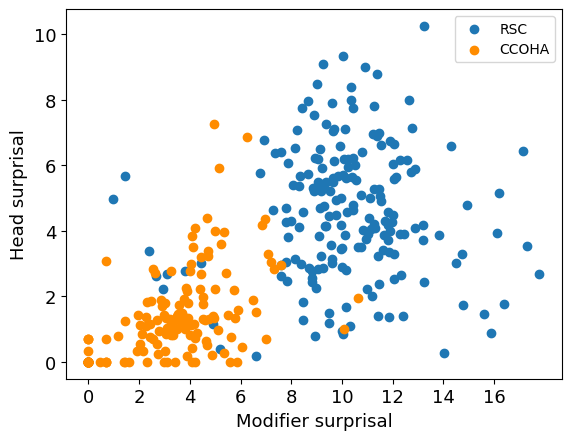

In [10]:
plt.rc('axes', labelsize=13)
plt.rc('ytick', labelsize=13)
plt.rc('xtick', labelsize=13)
mod_surps = []
head_surps = []
for compound, features in all_features.items():
    mod_surps.append(features["avg_mod_surprisal_bin6"])
    head_surps.append(features["avg_head_surprisal_bin6"])
plt.scatter(mod_surps, head_surps, label="RSC")
#plt.show()

mod_surps_coha = []
head_surps_coha = []
for compound, features in all_features_coha.items():
    mod_surps_coha.append(features["avg_mod_surprisal_bin6"])
    head_surps_coha.append(features["avg_head_surprisal_bin6"])
plt.scatter(mod_surps_coha, head_surps_coha, color="darkorange", label="CCOHA")

axes = plt.gca()
plt.xlabel("Modifier surprisal")
plt.ylabel("Head surprisal")
plt.xticks(range(0, 18, 2))
plt.legend()
plt.show()
plt.rcdefaults()